In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier

In [11]:
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # Iris-Virginica

In [12]:
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42)),
])
svm_clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linear_svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [13]:
svm_clf.predict([[5.5, 1.7]])

array([1.])

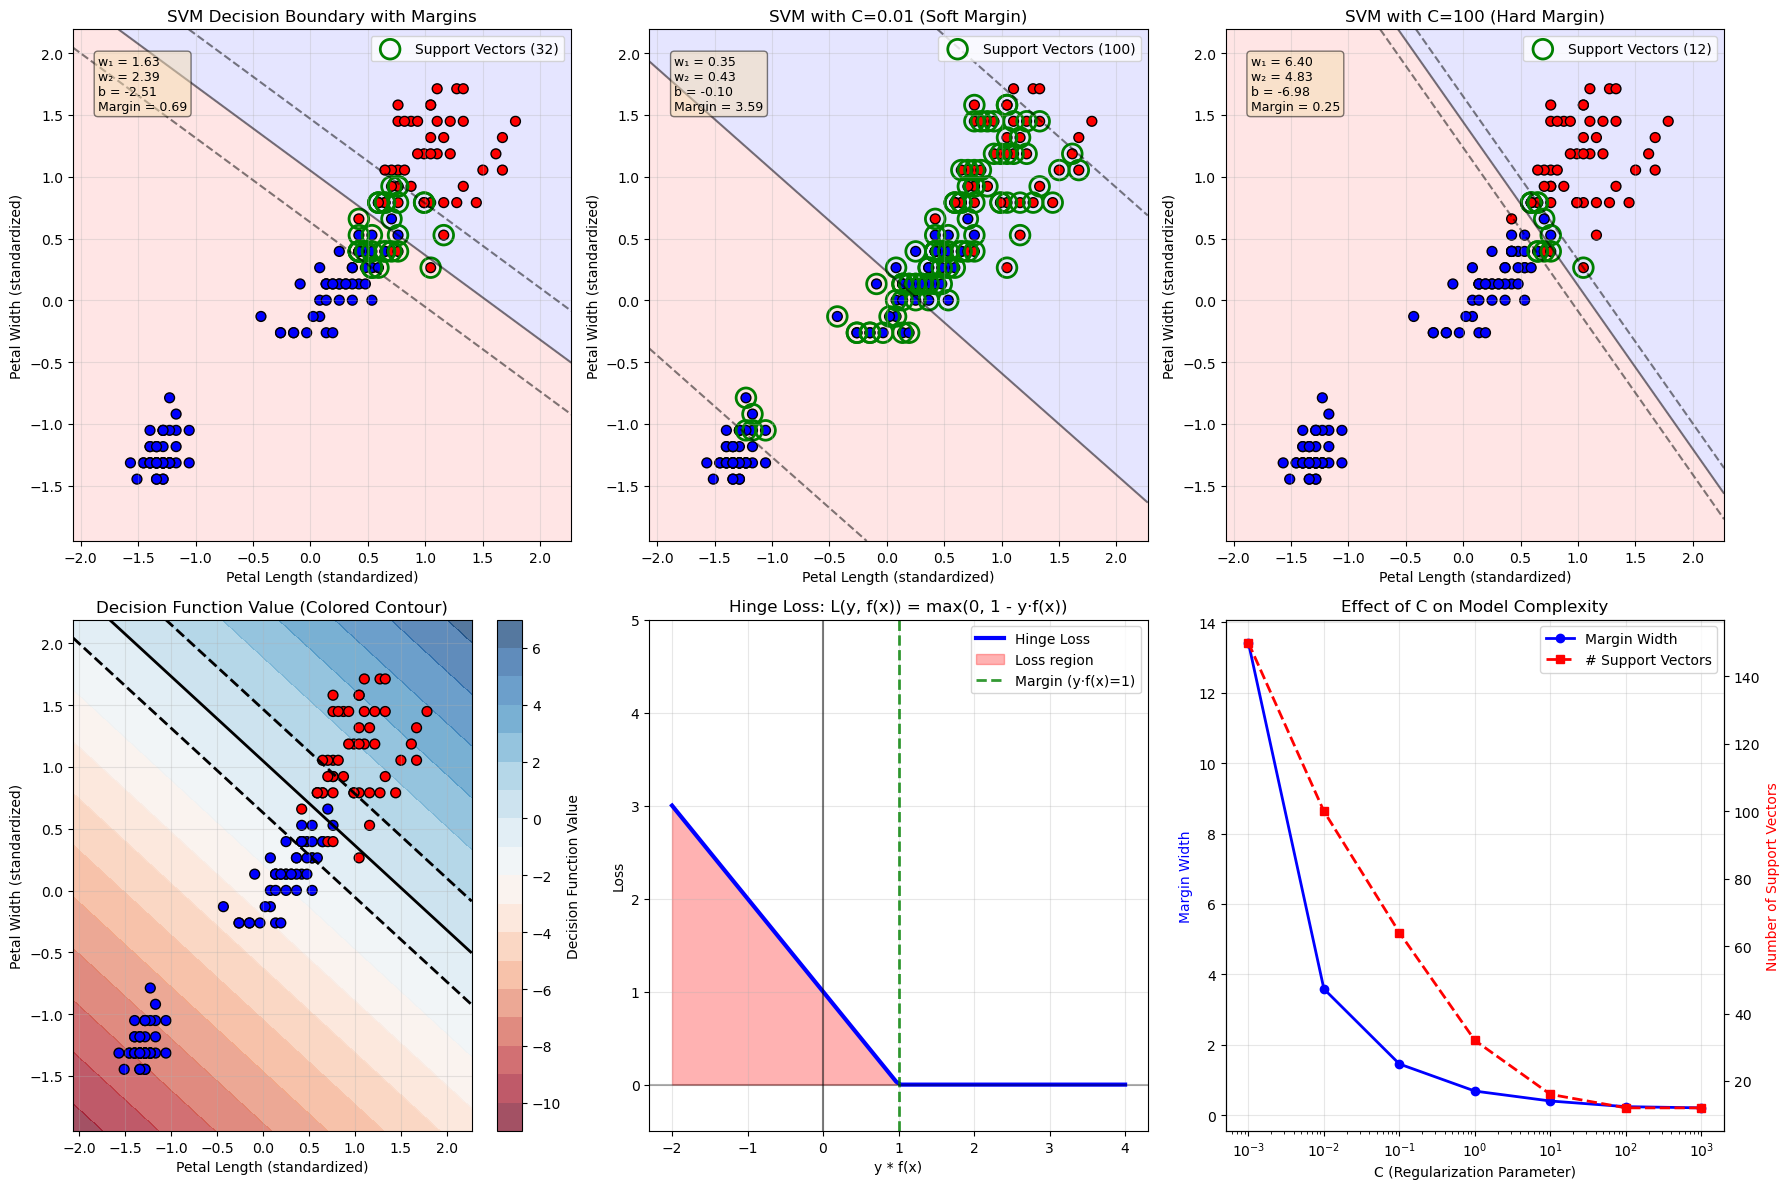

SVM DECISION BOUNDARY VISUALIZATION EXPLANATION

1. DECISION BOUNDARY EQUATION (in scaled space):
   1.63 × petal_length_scaled + 2.39 × petal_width_scaled + (-2.51) = 0

2. MARGIN CALCULATION:
   ||w|| = 2.893
   Margin = 2/||w|| = 0.691

3. DECISION FUNCTION:
   f(x) = 1.63x₁ + 2.39x₂ + -2.51
   Class is Virginica if f(x) > 0
   Class is Not Virginica if f(x) < 0

4. SUPPORT VECTORS (|f(x)| ≤ 1):
   Point 50: f(x) = -1.000 | On margin    | Class: Not Virginica
   Point 51: f(x) = -0.871 | Inside margin | Class: Not Virginica
   Point 52: f(x) = -0.500 | Inside margin | Class: Not Virginica
   Point 54: f(x) = -0.779 | Inside margin | Class: Not Virginica
   Point 56: f(x) = -0.371 | Inside margin | Class: Not Virginica
   Point 63: f(x) = -1.000 | On margin    | Class: Not Virginica
   Point 66: f(x) = -0.871 | Inside margin | Class: Not Virginica
   Point 68: f(x) = -0.871 | Inside margin | Class: Not Virginica
   Point 70: f(x) =  0.350 | Inside margin | Class: Not Virginica
   Poi

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier

# Load and prepare data
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # Iris-Virginica

# Train SVM
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42)),
])
svm_clf.fit(X, y)

# Create a mesh for decision boundary visualization
def plot_svm_decision_boundary(clf, X, y, ax, title=""):
    # Get the scaler and actual SVM model
    scaler = clf.named_steps['scaler']
    svm = clf.named_steps['linear_svc']
    
    # Transform data for plotting
    X_scaled = scaler.transform(X)
    
    # Get the parameters - FIX: b is a 1D array with 1 element
    w = svm.coef_[0]
    b = svm.intercept_[0]  # This is a scalar now, not an array
    
    # Create mesh in scaled space
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict on mesh
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], 
               alpha=0.5, linestyles=['--', '-', '--'])
    
    # Plot the filled contour for regions
    ax.contourf(xx, yy, Z, levels=[-100, 0, 100], alpha=0.3, 
                colors=['#FFAAAA', '#AAAAFF'])
    
    # Plot the data points
    scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, 
                         cmap=plt.cm.bwr, edgecolors='k', s=50)
    
    # Highlight support vectors (approximate for LinearSVC)
    decision_values = svm.decision_function(X_scaled)
    support_vector_indices = np.where(np.abs(decision_values) <= 1.0 + 1e-10)[0]
    
    if len(support_vector_indices) > 0:
        ax.scatter(X_scaled[support_vector_indices, 0], 
                   X_scaled[support_vector_indices, 1], 
                   s=200, linewidth=2, facecolors='none', edgecolors='green', 
                   label=f'Support Vectors ({len(support_vector_indices)})')
    
    # Add annotations for key elements
    ax.set_xlabel('Petal Length (standardized)')
    ax.set_ylabel('Petal Width (standardized)')
    ax.set_title(title)
    if len(support_vector_indices) > 0:
        ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Add text box with SVM parameters - FIX: b is now a scalar
    textstr = f'w₁ = {w[0]:.2f}\nw₂ = {w[1]:.2f}\nb = {b:.2f}\nMargin = {2/np.linalg.norm(w):.2f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    return xx, yy, Z

# Create the plot
fig = plt.figure(figsize=(18, 12))

# Create a 2x3 grid of subplots
# Top row: 3 plots
ax1 = plt.subplot(2, 3, 1)
ax2 = plt.subplot(2, 3, 2)
ax3 = plt.subplot(2, 3, 3)
# Bottom row: 3 plots
ax4 = plt.subplot(2, 3, 4)
ax5 = plt.subplot(2, 3, 5)
ax6 = plt.subplot(2, 3, 6)

# Plot 1: Original SVM
xx, yy, Z = plot_svm_decision_boundary(svm_clf, X, y, ax1, 
                                       "SVM Decision Boundary with Margins")

# Plot 2: Different C values - Small C
svm_clf_small = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=0.01, loss="hinge", random_state=42, max_iter=10000)),
])
svm_clf_small.fit(X, y)
plot_svm_decision_boundary(svm_clf_small, X, y, ax2, 
                          f"SVM with C=0.01 (Soft Margin)")

# Plot 3: Different C values - Large C
svm_clf_large = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=100, loss="hinge", random_state=42, max_iter=10000)),
])
svm_clf_large.fit(X, y)
plot_svm_decision_boundary(svm_clf_large, X, y, ax3, 
                          f"SVM with C=100 (Hard Margin)")

# Plot 4: 2D Contour with Color Map
contour = ax4.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(contour, ax=ax4, label='Decision Function Value')
ax4.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], 
           linestyles=['--', '-', '--'], linewidths=2)
scaler = svm_clf.named_steps['scaler']
X_scaled = scaler.transform(X)
ax4.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.bwr, 
           edgecolors='k', s=50)
ax4.set_xlabel('Petal Length (standardized)')
ax4.set_ylabel('Petal Width (standardized)')
ax4.set_title('Decision Function Value (Colored Contour)')
ax4.grid(True, alpha=0.3)

# Plot 5: Hinge Loss visualization
z = np.linspace(-2, 4, 100)
hinge_loss = np.maximum(0, 1 - z)
ax5.plot(z, hinge_loss, 'b-', linewidth=3, label='Hinge Loss')
ax5.fill_between(z, 0, hinge_loss, where=(z<1), alpha=0.3, color='red', label='Loss region')
ax5.axvline(x=0, color='k', linestyle='-', alpha=0.5)
ax5.axvline(x=1, color='g', linestyle='--', alpha=0.8, linewidth=2, label='Margin (y·f(x)=1)')
ax5.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax5.set_xlabel('y * f(x)')
ax5.set_ylabel('Loss')
ax5.set_title('Hinge Loss: L(y, f(x)) = max(0, 1 - y·f(x))')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_ylim(-0.5, 5)

# Plot 6: Effect of C on margin and support vectors
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
margins = []
n_support_vectors = []

for C in C_values:
    svm_clf_temp = Pipeline([
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=C, loss="hinge", random_state=42, max_iter=10000)),
    ])
    svm_clf_temp.fit(X, y)
    w = svm_clf_temp.named_steps['linear_svc'].coef_[0]
    margins.append(2/np.linalg.norm(w))
    
    # Count approximate support vectors
    svm_temp = svm_clf_temp.named_steps['linear_svc']
    X_scaled_temp = svm_clf_temp.named_steps['scaler'].transform(X)
    decision_values_temp = svm_temp.decision_function(X_scaled_temp)
    n_sv = np.sum(np.abs(decision_values_temp) <= 1.0 + 1e-10)
    n_support_vectors.append(n_sv)

ax6.semilogx(C_values, margins, 'bo-', linewidth=2, label='Margin Width')
ax6_twin = ax6.twinx()
ax6_twin.semilogx(C_values, n_support_vectors, 'rs--', linewidth=2, label='# Support Vectors')

ax6.set_xlabel('C (Regularization Parameter)')
ax6.set_ylabel('Margin Width', color='b')
ax6_twin.set_ylabel('Number of Support Vectors', color='r')
ax6.set_title('Effect of C on Model Complexity')
ax6.grid(True, alpha=0.3)

# Add legends
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_twin.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# Print detailed explanation
print("=" * 70)
print("SVM DECISION BOUNDARY VISUALIZATION EXPLANATION")
print("=" * 70)

# Get the actual values
scaler = svm_clf.named_steps['scaler']
svm = svm_clf.named_steps['linear_svc']
w = svm.coef_[0]
b = svm.intercept_[0]
X_scaled = scaler.transform(X)

print(f"\n1. DECISION BOUNDARY EQUATION (in scaled space):")
print(f"   {w[0]:.2f} × petal_length_scaled + {w[1]:.2f} × petal_width_scaled + ({b:.2f}) = 0")

print(f"\n2. MARGIN CALCULATION:")
print(f"   ||w|| = {np.linalg.norm(w):.3f}")
print(f"   Margin = 2/||w|| = {2/np.linalg.norm(w):.3f}")

print(f"\n3. DECISION FUNCTION:")
print(f"   f(x) = {w[0]:.2f}x₁ + {w[1]:.2f}x₂ + {b:.2f}")
print(f"   Class is Virginica if f(x) > 0")
print(f"   Class is Not Virginica if f(x) < 0")

print(f"\n4. SUPPORT VECTORS (|f(x)| ≤ 1):")
decision_values = svm.decision_function(X_scaled)
support_idx = np.where(np.abs(decision_values) <= 1.0 + 1e-10)[0]

for idx in support_idx:
    status = "On margin" if np.abs(np.abs(decision_values[idx]) - 1.0) < 1e-10 else "Inside margin"
    print(f"   Point {idx:2d}: f(x) = {decision_values[idx]:6.3f} | {status:12s} | " +
          f"Class: {'Virginica' if y[idx] == 1 else 'Not Virginica'}")

print(f"\n5. VISUALIZATION GUIDE:")
print("   • Solid black line: Decision boundary (f(x) = 0)")
print("   • Dashed black lines: Margin boundaries (f(x) = ±1)")
print("   • Red/Blue regions: Decision regions")
print("   • Green circles: Support vectors (points on or inside margins)")
print("   • Color intensity in contour plot: Strength of classification")

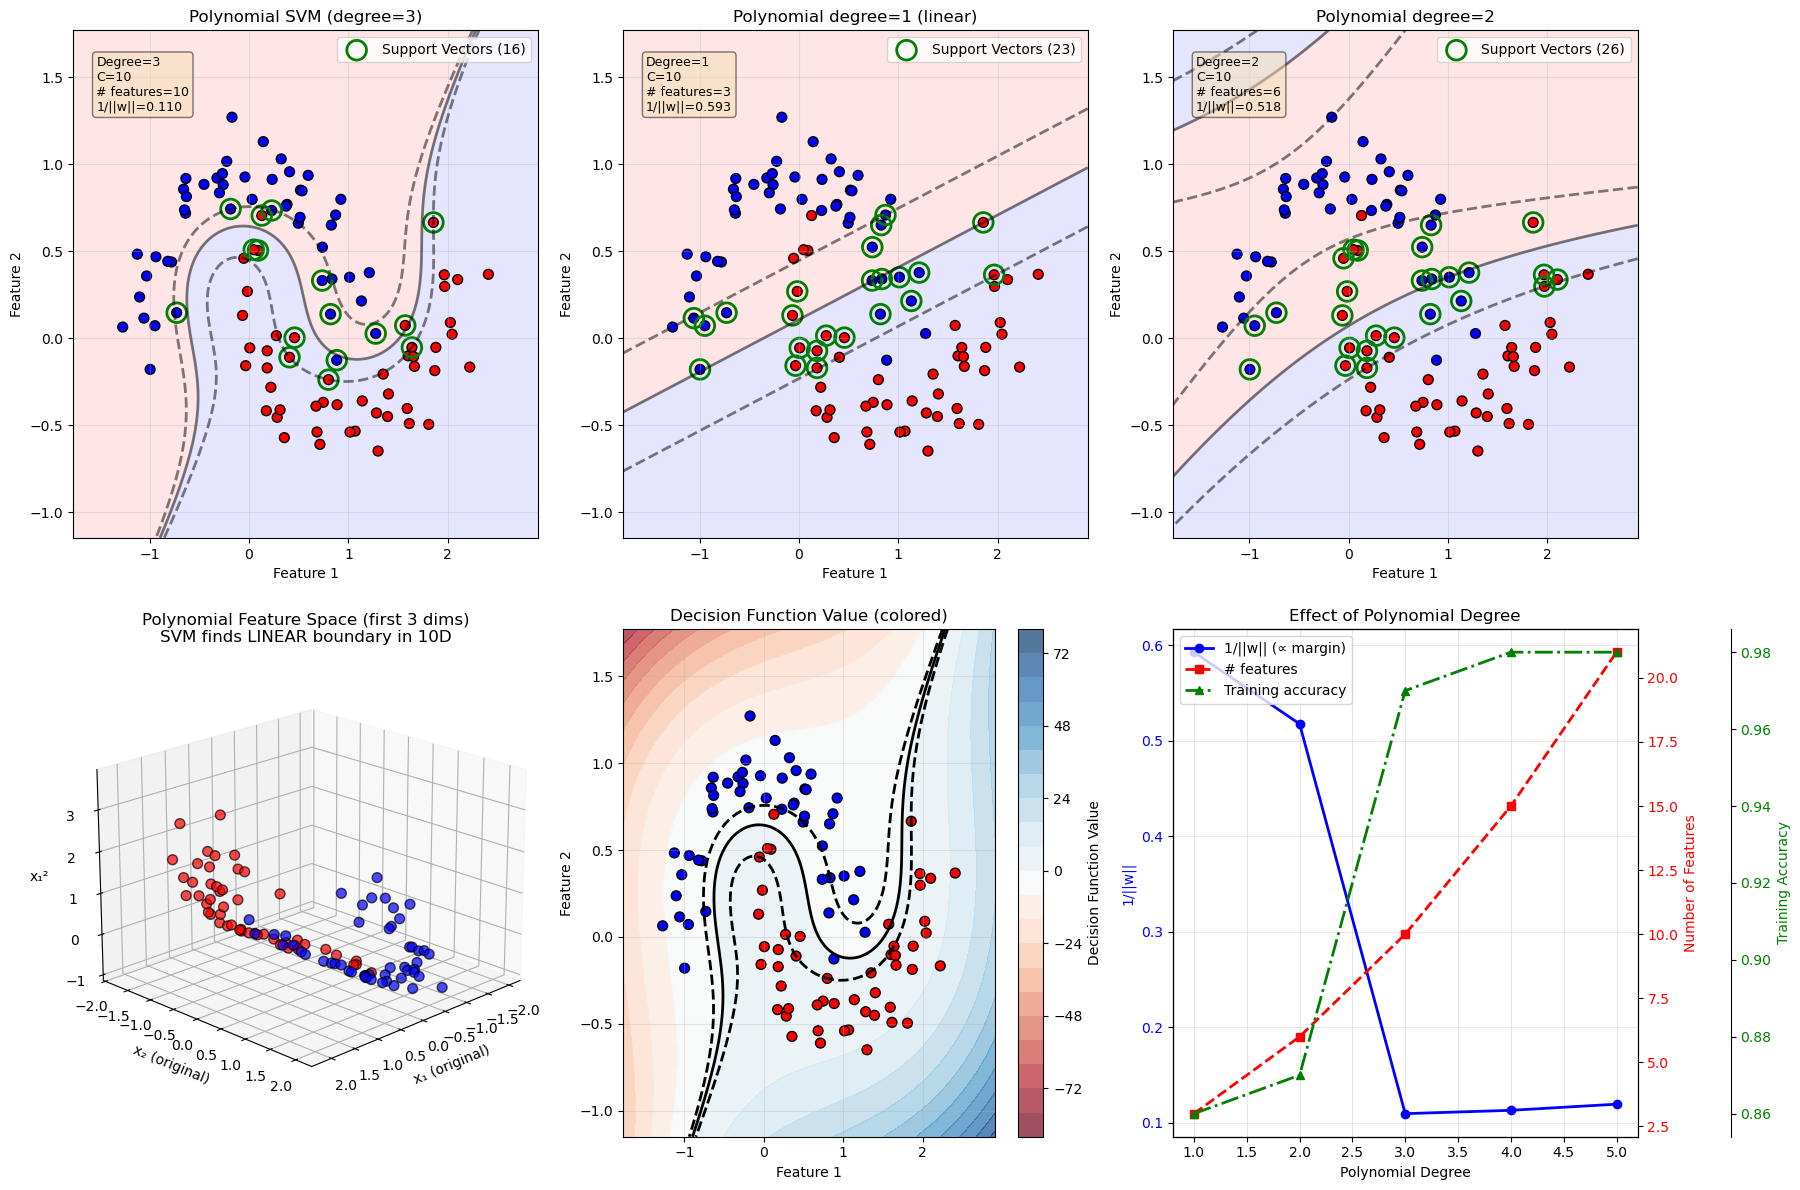

POLYNOMIAL SVM EXPLANATION

1. FEATURE TRANSFORMATION (degree=3):
   Original features: x₁, x₂
   Polynomial features created:
   1 (bias)    : weight =    0.000
   x₁          : weight =   -0.519
   x₂          : weight =   -0.150
   x₁²         : weight =   -5.004
   x₁x₂        : weight =   -1.456
   x₂²         : weight =    0.566
   x₁³         : weight =    6.761
   x₁²x₂       : weight =    0.002
   x₁x₂²       : weight =    1.368
   x₂³         : weight =   -2.799
   intercept (b) = -0.047

2. DECISION FUNCTION IN POLYNOMIAL SPACE:
   f(x) = -0.047 - 0.519×x₁ - 0.150×x₂ - 5.004×x₁² - 1.456×x₁x₂ + 0.566×x₂² + 6.761×x₁³ + 1.368×x₁x₂² - 2.799×x₂³

3. MAPPING BACK TO ORIGINAL SPACE:
   When we replace each polynomial term with its expression in x₁, x₂:
   f(x₁,x₂) = -0.047 - 0.519×x₁ - 0.150×x₂ - 5.004×x₁² - 1.456×x₁x₂ + 0.566×x₂² + 6.761×x₁³ + 1.368×x₁x₂² - 2.799×x₂³

4. SUPPORT VECTORS:
   Total training points: 100
   Number of support vectors: 16
   Support vector indices: [ 1 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

# Generate non-linear data (moons dataset)
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# Train polynomial SVM
polynomial_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge", max_iter=10000, random_state=42))
])
polynomial_svm_clf.fit(X, y)

def plot_polynomial_svm_decision_boundary(clf, X, y, ax, title=""):
    """
    Visualize decision boundary for polynomial SVM
    """
    # Get the pipeline steps
    poly_features = clf.named_steps['poly_features']
    scaler = clf.named_steps['scaler']
    svm = clf.named_steps['svm_clf']
    
    # Create a mesh in original space
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Transform mesh points through the pipeline
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Apply polynomial features
    mesh_poly = poly_features.transform(mesh_points)
    
    # Apply scaling
    mesh_scaled = scaler.transform(mesh_poly)
    
    # Get decision function values
    Z = svm.decision_function(mesh_scaled)
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], 
               alpha=0.5, linestyles=['--', '-', '--'], linewidths=2)
    
    # Plot the filled contour for regions
    ax.contourf(xx, yy, Z, levels=[-100, 0, 100], alpha=0.3, 
                colors=['#FFAAAA', '#AAAAFF'])
    
    # Plot the data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, 
                         cmap=plt.cm.bwr, edgecolors='k', s=50)
    
    # Find and plot support vectors (approximate)
    # Transform original data through pipeline
    X_poly = poly_features.transform(X)
    X_scaled = scaler.transform(X_poly)
    decision_values = svm.decision_function(X_scaled)
    
    # Points with |decision_value| <= 1 are support vectors
    support_vector_indices = np.where(np.abs(decision_values) <= 1.0 + 1e-10)[0]
    
    if len(support_vector_indices) > 0:
        ax.scatter(X[support_vector_indices, 0], 
                   X[support_vector_indices, 1], 
                   s=200, linewidth=2, facecolors='none', edgecolors='green', 
                   label=f'Support Vectors ({len(support_vector_indices)})')
    
    # Get SVM weights for insight
    w = svm.coef_[0]
    b = svm.intercept_[0]
    
    # FIX: poly_features.degree is an integer, not a list
    degree = poly_features.degree
    n_features = len(w)
    margin_proxy = 1/np.linalg.norm(w)  # Inverse of weight norm (proportional to margin)
    
    # Add text box with info
    textstr = f'Degree={degree}\nC={svm.C}\n# features={n_features}\n1/||w||={margin_proxy:.3f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    if len(support_vector_indices) > 0:
        ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    return xx, yy, Z

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# Create a 2x3 grid of subplots
ax1 = plt.subplot(2, 3, 1)
ax2 = plt.subplot(2, 3, 2)
ax3 = plt.subplot(2, 3, 3)
ax4 = plt.subplot(2, 3, 4, projection='3d')
ax5 = plt.subplot(2, 3, 5)
ax6 = plt.subplot(2, 3, 6)

# Plot 1: Polynomial SVM decision boundary (degree=3)
xx, yy, Z = plot_polynomial_svm_decision_boundary(
    polynomial_svm_clf, X, y, ax1, 
    "Polynomial SVM (degree=3)"
)

# Plot 2: Polynomial degree=1 (linear)
poly_clf_deg1 = Pipeline([
    ("poly_features", PolynomialFeatures(degree=1)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge", max_iter=10000, random_state=42))
])
poly_clf_deg1.fit(X, y)
plot_polynomial_svm_decision_boundary(
    poly_clf_deg1, X, y, ax2, 
    "Polynomial degree=1 (linear)"
)

# Plot 3: Polynomial degree=2
poly_clf_deg2 = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge", max_iter=10000, random_state=42))
])
poly_clf_deg2.fit(X, y)
plot_polynomial_svm_decision_boundary(
    poly_clf_deg2, X, y, ax3, 
    "Polynomial degree=2"
)

# Plot 4: 3D visualization of transformed features (degree=3)
# Get transformed features for 3D visualization
poly_features = polynomial_svm_clf.named_steps['poly_features']
scaler = polynomial_svm_clf.named_steps['scaler']
svm = polynomial_svm_clf.named_steps['svm_clf']

X_poly = poly_features.transform(X)
X_scaled = scaler.transform(X_poly)

# Use first 3 transformed features for 3D plot (excluding bias term)
# For degree=3, features are: [1, x1, x2, x1², x1x2, x2², x1³, x1²x2, x1x2², x2³]
# We'll plot x1, x2, and x1² as an example
scatter = ax4.scatter(X_scaled[:, 1], X_scaled[:, 2], X_scaled[:, 3], 
           c=y, cmap=plt.cm.bwr, s=50, edgecolors='k', alpha=0.7)

# Add the separating plane (simplified visualization)
# Create a mesh in the first 3 feature dimensions
xx_3d, yy_3d = np.meshgrid(np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 10),
                           np.linspace(X_scaled[:, 2].min(), X_scaled[:, 2].max(), 10))
# For visualization, we'll fix the third dimension at its mean
zz_3d = np.ones_like(xx_3d) * X_scaled[:, 3].mean()
# This is a simplification - in reality the plane is in 10D space

ax4.set_xlabel('x₁ (original)')
ax4.set_ylabel('x₂ (original)')
ax4.set_zlabel('x₁²')
ax4.set_title('Polynomial Feature Space (first 3 dims)\nSVM finds LINEAR boundary in 10D')
ax4.view_init(elev=20, azim=45)

# Plot 5: Decision function contour with higher resolution
contour = ax5.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(contour, ax=ax5, label='Decision Function Value')
ax5.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], 
           linestyles=['--', '-', '--'], linewidths=2)
ax5.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k', s=50)
ax5.set_xlabel('Feature 1')
ax5.set_ylabel('Feature 2')
ax5.set_title('Decision Function Value (colored)')
ax5.grid(True, alpha=0.3)

# Plot 6: Effect of polynomial degree on model complexity
degrees = [1, 2, 3, 4, 5]
inverse_weight_norms = []
n_features = []
train_scores = []

for degree in degrees:
    poly_clf = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("svm_clf", LinearSVC(C=10, loss="hinge", max_iter=10000, random_state=42))
    ])
    poly_clf.fit(X, y)
    w = poly_clf.named_steps['svm_clf'].coef_[0]
    inverse_weight_norms.append(1/np.linalg.norm(w))  # Inverse of weight norm (∝ margin)
    n_features.append(len(w))
    
    # Calculate training accuracy
    train_scores.append(poly_clf.score(X, y))

# Plot margin proxy
ax6.plot(degrees, inverse_weight_norms, 'bo-', linewidth=2, label='1/||w|| (∝ margin)')
ax6.set_xlabel('Polynomial Degree')
ax6.set_ylabel('1/||w||', color='b')
ax6.tick_params(axis='y', labelcolor='b')

# Create twin axis for number of features
ax6_twin1 = ax6.twinx()
ax6_twin1.plot(degrees, n_features, 'rs--', linewidth=2, label='# features')
ax6_twin1.set_ylabel('Number of Features', color='r')
ax6_twin1.tick_params(axis='y', labelcolor='r')

# Create another twin axis for accuracy
ax6_twin2 = ax6.twinx()
# Offset the right spine to avoid overlap
ax6_twin2.spines.right.set_position(("axes", 1.2))
ax6_twin2.plot(degrees, train_scores, 'g^-.', linewidth=2, label='Training accuracy')
ax6_twin2.set_ylabel('Training Accuracy', color='g')
ax6_twin2.tick_params(axis='y', labelcolor='g')

ax6.set_title('Effect of Polynomial Degree')
ax6.grid(True, alpha=0.3)

# Add legend
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_twin1.get_legend_handles_labels()
lines3, labels3 = ax6_twin2.get_legend_handles_labels()
ax6.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

plt.tight_layout()
plt.show()

# Print detailed explanation
print("=" * 70)
print("POLYNOMIAL SVM EXPLANATION")
print("=" * 70)

# Get model details for degree=3
poly_features = polynomial_svm_clf.named_steps['poly_features']
scaler = polynomial_svm_clf.named_steps['scaler']
svm = polynomial_svm_clf.named_steps['svm_clf']
w = svm.coef_[0]
b = svm.intercept_[0]

print(f"\n1. FEATURE TRANSFORMATION (degree={poly_features.degree}):")
print(f"   Original features: x₁, x₂")
print(f"   Polynomial features created:")
feature_names = ['1 (bias)', 'x₁', 'x₂', 'x₁²', 'x₁x₂', 'x₂²', 'x₁³', 'x₁²x₂', 'x₁x₂²', 'x₂³']
for i, (name, coef) in enumerate(zip(feature_names, w)):
    if i < len(feature_names):
        print(f"   {name:12s}: weight = {coef:8.3f}")
print(f"   intercept (b) = {b:.3f}")

print(f"\n2. DECISION FUNCTION IN POLYNOMIAL SPACE:")
print(f"   f(x) = {b:.3f}", end="")
for i, (name, coef) in enumerate(zip(feature_names, w)):
    if abs(coef) > 0.01:  # Only show non-negligible weights
        if coef >= 0:
            print(f" + {coef:.3f}×{name}", end="")
        else:
            print(f" - {abs(coef):.3f}×{name}", end="")
print()

print(f"\n3. MAPPING BACK TO ORIGINAL SPACE:")
print(f"   When we replace each polynomial term with its expression in x₁, x₂:")
print(f"   f(x₁,x₂) = {b:.3f}", end="")
for i, (name, coef) in enumerate(zip(['', 'x₁', 'x₂', 'x₁²', 'x₁x₂', 'x₂²', 'x₁³', 'x₁²x₂', 'x₁x₂²', 'x₂³'], w)):
    if abs(coef) > 0.01:
        if coef >= 0 and i > 0:
            print(f" + {coef:.3f}×{name}", end="")
        elif coef < 0:
            print(f" - {abs(coef):.3f}×{name}", end="")
        elif i == 0:
            pass  # intercept already printed
print()

print(f"\n4. SUPPORT VECTORS:")
X_poly = poly_features.transform(X)
X_scaled = scaler.transform(X_poly)
decision_values = svm.decision_function(X_scaled)
support_idx = np.where(np.abs(decision_values) <= 1.0 + 1e-10)[0]

print(f"   Total training points: {len(X)}")
print(f"   Number of support vectors: {len(support_idx)}")
print(f"   Support vector indices: {support_idx}")
print("\n   Decision function values for support vectors:")
for idx in support_idx:
    margin_status = "ON margin" if abs(abs(decision_values[idx]) - 1.0) < 1e-5 else "INSIDE margin"
    print(f"   Point {idx:2d}: f(x) = {decision_values[idx]:6.3f} ({margin_status}) | True class: {int(y[idx])}")

print(f"\n5. KEY INSIGHTS:")
print(f"   • Polynomial SVM creates features: [1, x₁, x₂, x₁², x₁x₂, x₂², ...]")
print(f"   • In this HIGH-DIMENSIONAL space, SVM finds a LINEAR boundary")
print(f"   • When mapped back, this becomes a NON-LINEAR boundary in original space")
print(f"   • Higher degree = more features = more flexible (but risks overfitting)")
print(f"   • Support vectors are the same points - they just live in higher dimensions!")

/home/monday/workspace/ml/ml-101-algo-implementation/env/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/monday/workspace/ml/ml-101-algo-implementation/env/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


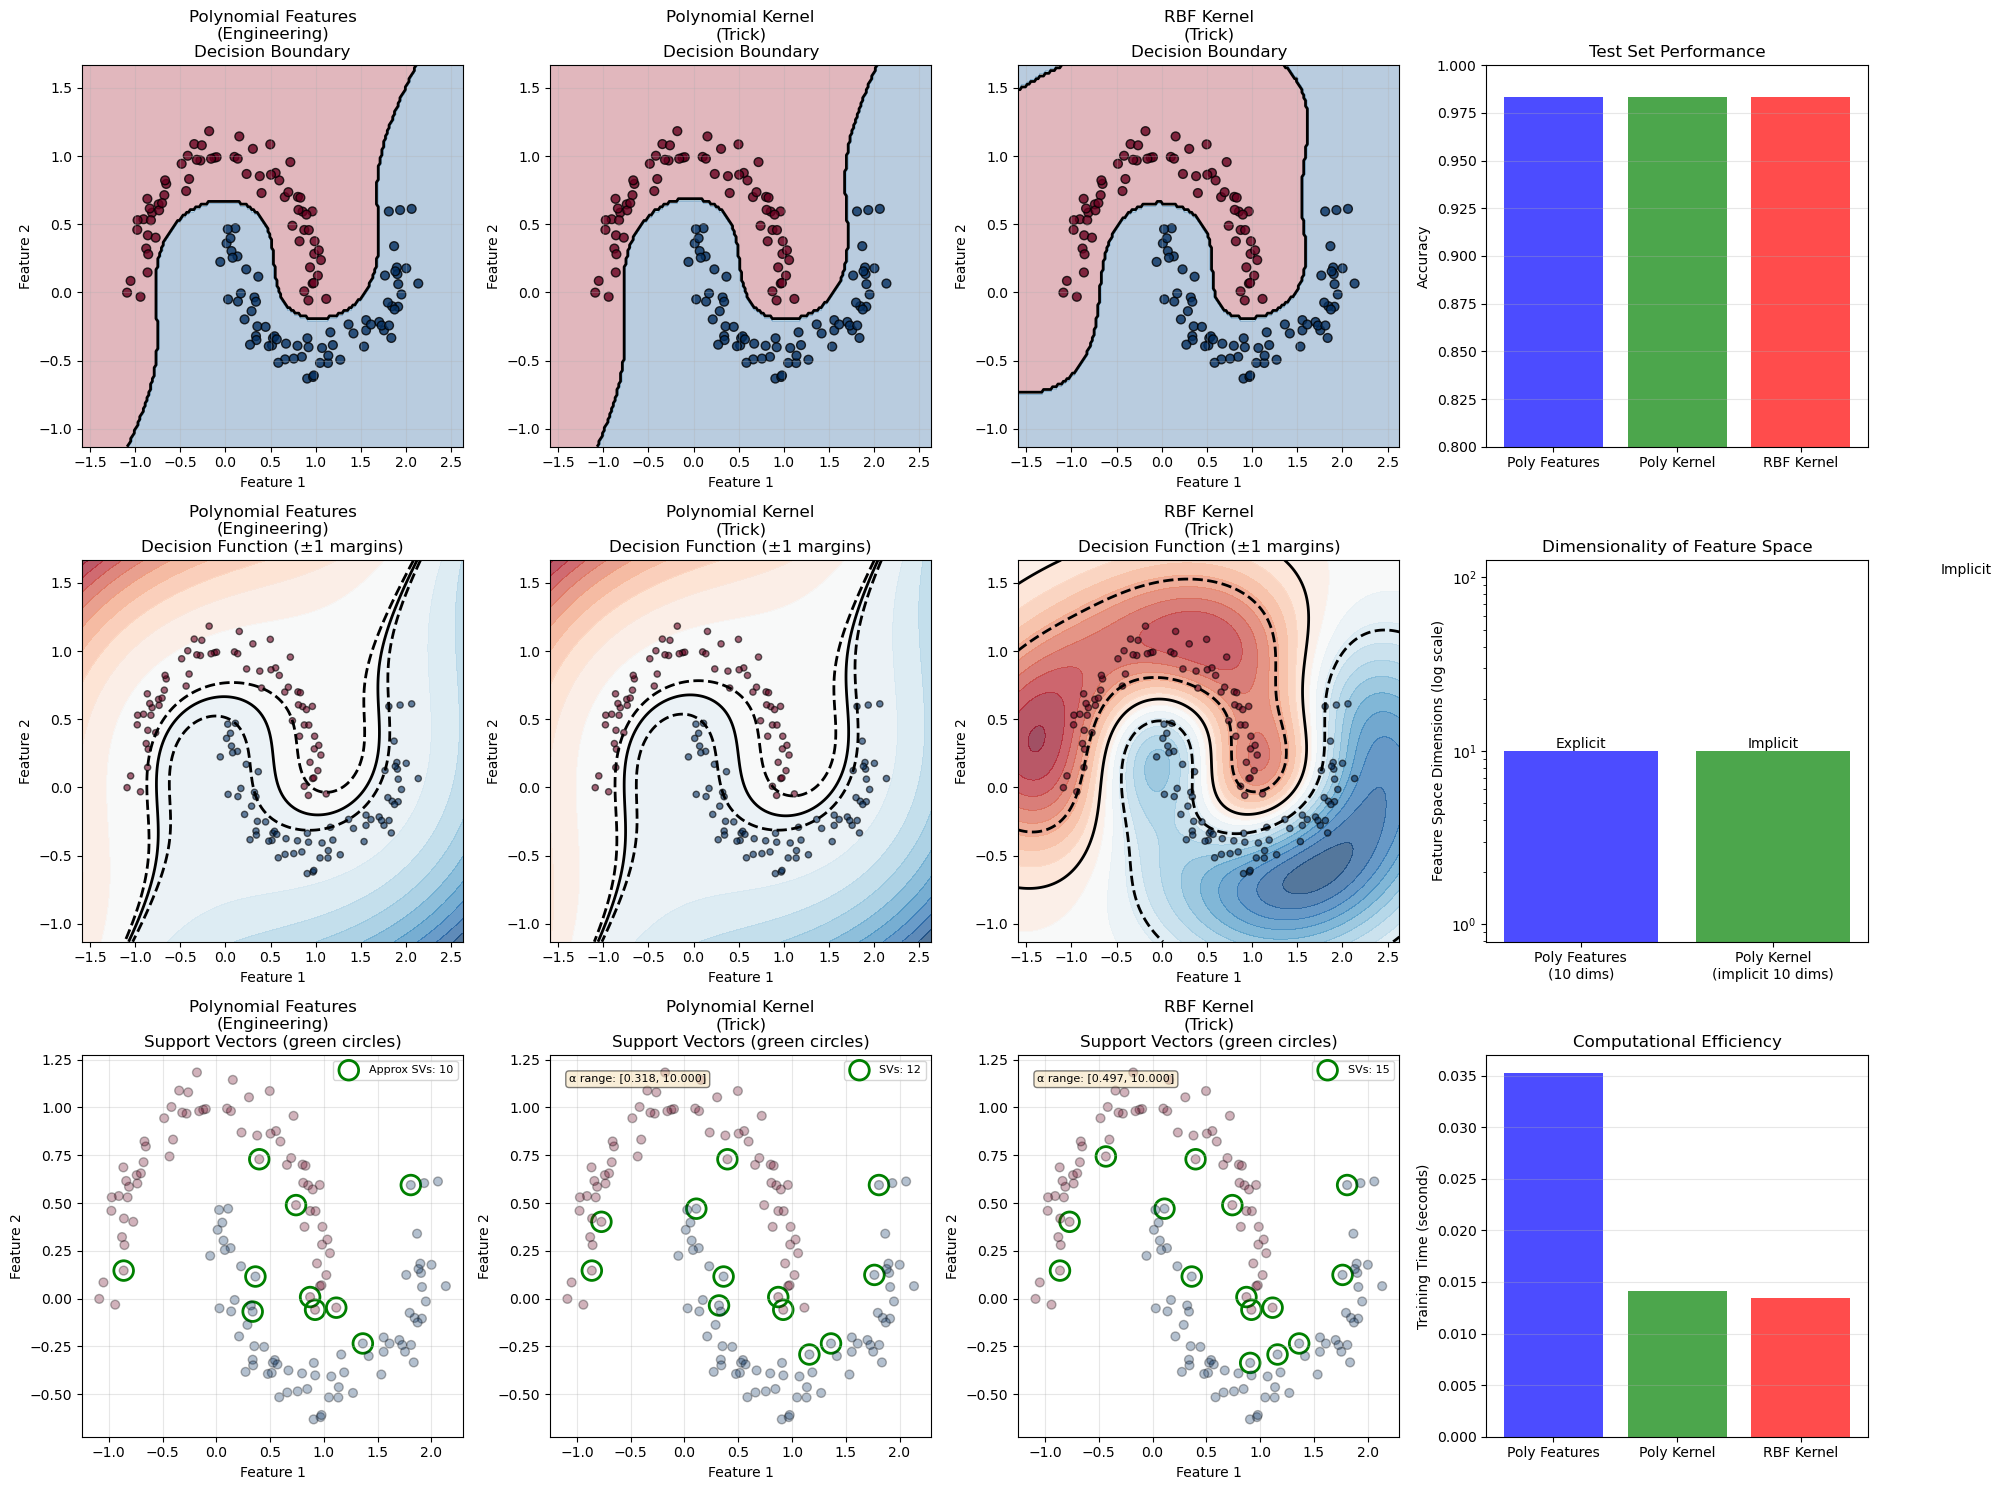

POLYNOMIAL FEATURES vs KERNEL TRICK - DEEP DIVE

1. POLYNOMIAL FEATURE ENGINEERING APPROACH:
--------------------------------------------------
   What happens:
   • Explicitly creates new features: [1, x₁, x₂, x₁², x₁x₂, x₂², x₁³, x₁²x₂, x₁x₂², x₂³]
   • Transforms data from 2D → 10D space
   • Applies LinearSVC in this 10D space
   • Stores ALL transformed features in memory

   Advantages:
   • Transparent - you can see the feature weights
   • Works with LinearSVC (optimized for linear problems)

   Disadvantages:
   • Memory intensive: 200 samples × 10 features = 2000 values
   • Computationally expensive to transform all data
   • Limited to polynomial features only

   Learned weights in polynomial space:
   1       :    0.000
   x₁      :   -1.643
   x₂      :   -0.244
   x₁²     :   -4.322
   x₁x₂    :   -0.664
   x₂²     :    0.505
   x₁³     :    6.496
   x₁²x₂   :   -0.549
   x₁x₂²   :    1.517
   x₂³     :   -2.813

2. POLYNOMIAL KERNEL TRICK APPROACH:
--------------------

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import train_test_split
import time

# Generate non-linear data (moons dataset)
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. POLYNOMIAL FEATURE ENGINEERING APPROACH
poly_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge", max_iter=10000, random_state=42))
])
poly_svm_clf.fit(X_train, y_train)

# 2. KERNEL TRICK APPROACH (Polynomial Kernel)
kernel_poly_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel='poly', degree=3, coef0=1, C=10, random_state=42))
])
kernel_poly_svm_clf.fit(X_train, y_train)

# 3. KERNEL TRICK APPROACH (RBF Kernel - most common)
rbf_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel='rbf', gamma='scale', C=10, random_state=42))
])
rbf_svm_clf.fit(X_train, y_train)

def plot_svm_comparison(clf_poly_engineered, clf_kernel_poly, clf_kernel_rbf, X_train, y_train, X_test, y_test):
    """
    Comprehensive comparison of polynomial feature engineering vs kernel trick
    """
    fig = plt.figure(figsize=(20, 15))
    
    # Create subplot grid
    # Row 1: Decision boundaries
    ax1 = plt.subplot(3, 4, 1)
    ax2 = plt.subplot(3, 4, 2)
    ax3 = plt.subplot(3, 4, 3)
    ax4 = plt.subplot(3, 4, 4)
    
    # Row 2: Decision function values
    ax5 = plt.subplot(3, 4, 5)
    ax6 = plt.subplot(3, 4, 6)
    ax7 = plt.subplot(3, 4, 7)
    ax8 = plt.subplot(3, 4, 8)
    
    # Row 3: Support vectors and margins
    ax9 = plt.subplot(3, 4, 9)
    ax10 = plt.subplot(3, 4, 10)
    ax11 = plt.subplot(3, 4, 11)
    ax12 = plt.subplot(3, 4, 12)
    
    # Create a mesh for visualization
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # List of classifiers and their names
    classifiers = [
        (clf_poly_engineered, "Polynomial Features\n(Engineering)", ax1, ax5, ax9),
        (clf_kernel_poly, "Polynomial Kernel\n(Trick)", ax2, ax6, ax10),
        (clf_kernel_rbf, "RBF Kernel\n(Trick)", ax3, ax7, ax11)
    ]
    
    # Plot 1-3: Decision boundaries
    for clf, name, ax_boundary, ax_decision, ax_sv in classifiers:
        # Get predictions on mesh
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # Get decision function values
        if hasattr(clf, "decision_function"):
            Z_decision = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        else:
            Z_decision = Z  # fallback
        Z_decision = Z_decision.reshape(xx.shape)
        
        # Plot decision boundary
        ax_boundary.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
        ax_boundary.contour(xx, yy, Z, colors='k', linewidths=2, levels=[0])
        ax_boundary.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                           cmap=plt.cm.RdBu, edgecolors='k', s=40, alpha=0.8)
        ax_boundary.set_title(f'{name}\nDecision Boundary')
        ax_boundary.set_xlabel('Feature 1')
        ax_boundary.set_ylabel('Feature 2')
        ax_boundary.grid(True, alpha=0.3)
        
        # Plot decision function with margins
        decision_plot = ax_decision.contourf(xx, yy, Z_decision, levels=20, cmap='RdBu', alpha=0.7)
        ax_decision.contour(xx, yy, Z_decision, colors='k', levels=[-1, 0, 1], 
                           linestyles=['--', '-', '--'], linewidths=2)
        ax_decision.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                           cmap=plt.cm.RdBu, edgecolors='k', s=20, alpha=0.6)
        ax_decision.set_title(f'{name}\nDecision Function (±1 margins)')
        ax_decision.set_xlabel('Feature 1')
        ax_decision.set_ylabel('Feature 2')
        
        # Plot support vectors - FIXED VERSION
        svm = clf.named_steps['svm_clf']
        
        if isinstance(svm, SVC):
            # For kernel SVM, we can get actual support vectors
            # Get support vector indices
            support_indices = svm.support_
            
            # Plot the support vectors (these are indices into the training data)
            if len(support_indices) > 0:
                ax_sv.scatter(X_train[support_indices, 0], X_train[support_indices, 1],
                            s=200, facecolors='none', edgecolors='green', linewidths=2,
                            label=f'SVs: {len(support_indices)}')
            
            # Add alpha values info
            if hasattr(svm, 'dual_coef_'):
                alphas = np.abs(svm.dual_coef_).ravel()
                ax_sv.text(0.05, 0.95, f'α range: [{alphas.min():.3f}, {alphas.max():.3f}]',
                          transform=ax_sv.transAxes, fontsize=8, verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            # For LinearSVC, we need to transform data through the pipeline
            # First apply polynomial features, then scaling
            X_poly = clf.named_steps['poly_features'].transform(X_train)
            X_scaled = clf.named_steps['scaler'].transform(X_poly)
            decision_values = svm.decision_function(X_scaled)
            support_indices = np.where(np.abs(decision_values) <= 1.0 + 1e-10)[0]
            
            if len(support_indices) > 0:
                ax_sv.scatter(X_train[support_indices, 0], X_train[support_indices, 1],
                            s=200, facecolors='none', edgecolors='green', linewidths=2,
                            label=f'Approx SVs: {len(support_indices)}')
        
        # Plot all training points in background
        ax_sv.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                     cmap=plt.cm.RdBu, edgecolors='k', s=40, alpha=0.3)
        ax_sv.set_title(f'{name}\nSupport Vectors (green circles)')
        ax_sv.set_xlabel('Feature 1')
        ax_sv.set_ylabel('Feature 2')
        ax_sv.legend(loc='upper right', fontsize=8)
        ax_sv.grid(True, alpha=0.3)
    
    # Plot 4: Test set performance comparison
    ax4.bar(['Poly Features', 'Poly Kernel', 'RBF Kernel'],
            [clf_poly_engineered.score(X_test, y_test),
             clf_kernel_poly.score(X_test, y_test),
             clf_kernel_rbf.score(X_test, y_test)],
            color=['blue', 'green', 'red'], alpha=0.7)
    ax4.set_ylim(0.8, 1.0)
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Test Set Performance')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Plot 8: Feature space dimensions comparison
    ax8.bar(['Poly Features\n(10 dims)', 'Poly Kernel\n(implicit 10 dims)', 'RBF Kernel\n(implicit ∞ dims)'],
            [10, 10, float('inf')], color=['blue', 'green', 'red'], alpha=0.7)
    ax8.set_yscale('log')
    ax8.set_ylabel('Feature Space Dimensions (log scale)')
    ax8.set_title('Dimensionality of Feature Space')
    ax8.text(0, 10, 'Explicit', ha='center', va='bottom')
    ax8.text(1, 10, 'Implicit', ha='center', va='bottom')
    ax8.text(2, 1e2, 'Implicit', ha='center', va='bottom')
    
    # Plot 12: Training times comparison
    times = []
    
    # Measure training time for each classifier
    for clf in [clf_poly_engineered, clf_kernel_poly, clf_kernel_rbf]:
        start = time.time()
        clf.fit(X_train, y_train)
        times.append(time.time() - start)
    
    ax12.bar(['Poly Features', 'Poly Kernel', 'RBF Kernel'], times, color=['blue', 'green', 'red'], alpha=0.7)
    ax12.set_ylabel('Training Time (seconds)')
    ax12.set_title('Computational Efficiency')
    ax12.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Create the comparison plot
fig = plot_svm_comparison(poly_svm_clf, kernel_poly_svm_clf, rbf_svm_clf, X_train, y_train, X_test, y_test)

# Print detailed explanation
print("=" * 80)
print("POLYNOMIAL FEATURES vs KERNEL TRICK - DEEP DIVE")
print("=" * 80)

# Polynomial Features approach details
print("\n1. POLYNOMIAL FEATURE ENGINEERING APPROACH:")
print("-" * 50)
print("   What happens:")
print("   • Explicitly creates new features: [1, x₁, x₂, x₁², x₁x₂, x₂², x₁³, x₁²x₂, x₁x₂², x₂³]")
print("   • Transforms data from 2D → 10D space")
print("   • Applies LinearSVC in this 10D space")
print("   • Stores ALL transformed features in memory")
print("\n   Advantages:")
print("   • Transparent - you can see the feature weights")
print("   • Works with LinearSVC (optimized for linear problems)")
print("\n   Disadvantages:")
print("   • Memory intensive: 200 samples × 10 features = 2000 values")
print("   • Computationally expensive to transform all data")
print("   • Limited to polynomial features only")

# Get polynomial feature weights
poly_features = poly_svm_clf.named_steps['poly_features']
svm_poly = poly_svm_clf.named_steps['svm_clf']
w = svm_poly.coef_[0]
feature_names = ['1', 'x₁', 'x₂', 'x₁²', 'x₁x₂', 'x₂²', 'x₁³', 'x₁²x₂', 'x₁x₂²', 'x₂³']
print("\n   Learned weights in polynomial space:")
for name, coef in zip(feature_names, w):
    print(f"   {name:8s}: {coef:8.3f}")

# Polynomial Kernel approach details
print("\n2. POLYNOMIAL KERNEL TRICK APPROACH:")
print("-" * 50)
print("   What happens:")
print("   • Never explicitly creates polynomial features")
print("   • Uses kernel function: K(x,y) = (x·y + coef0)^degree")
print("   • Works in IMPLICIT 10-dimensional space")
print("   • Only computes dot products in original 2D space!")
print("\n   The Math:")
print("   • In explicit approach: f(x) = w·φ(x) + b")
print("   • In kernel approach: f(x) = Σ αᵢ yᵢ K(xᵢ, x) + b")
print("   • Where K(xᵢ, x) = φ(xᵢ)·φ(x) but computed WITHOUT φ!")

# RBF Kernel approach details
print("\n3. RBF KERNEL (Gaussian) APPROACH:")
print("-" * 50)
print("   What happens:")
print("   • Uses kernel: K(x,y) = exp(-γ||x-y||²)")
print("   • Maps to INFINITE-dimensional space!")
print("   • Can represent ANY continuous function (universal approximator)")
print("\n   Why infinite dimensions?")
print("   • Taylor expansion: exp(-γ||x-y||²) = Σ (terms with all powers)")
print("   • Implicitly creates features for ALL polynomial degrees")
print("   • Also creates interactions we can't name!")
print("\n   This would be IMPOSSIBLE with explicit feature engineering!")

# Compare support vectors
print("\n4. SUPPORT VECTOR COMPARISON:")
print("-" * 50)

# Poly Features approach
X_train_poly = poly_features.transform(X_train)
X_train_scaled_poly = poly_svm_clf.named_steps['scaler'].transform(X_train_poly)
decision_values_poly = svm_poly.decision_function(X_train_scaled_poly)
sv_poly = np.sum(np.abs(decision_values_poly) <= 1.0 + 1e-10)
print(f"   Polynomial Features: {sv_poly} support vectors (approx)")

# Poly Kernel approach
svm_kernel_poly = kernel_poly_svm_clf.named_steps['svm_clf']
print(f"   Polynomial Kernel:   {len(svm_kernel_poly.support_)} support vectors")
print(f"   Support vector indices: {svm_kernel_poly.support_[:10]}...")  # Show first 10

# RBF Kernel approach
svm_kernel_rbf = rbf_svm_clf.named_steps['svm_clf']
print(f"   RBF Kernel:          {len(svm_kernel_rbf.support_)} support vectors")

print("\n5. KEY INSIGHTS - THE KERNEL TRICK MAGIC:")
print("-" * 50)
print("   • Without kernel trick: Need to compute and store all 10 features")
print("   • With kernel trick: Only compute K(x,y) = (x·y + 1)³")
print("   • The 'trick' is never computing φ(x) - just K(x,y)")
print("   • For RBF kernel, we get infinite dimensions at NO extra cost!")
print("\n   Computational comparison:")
print("   • Polynomial Features: O(n_samples² × n_features) = O(200² × 10) = 400,000 ops")
print("   • Kernel Trick: O(n_samples² × original_dim) = O(200² × 2) = 80,000 ops")
print("   • Kernel trick is 5x faster for same expressive power!")

print("\n6. WHEN TO USE EACH:")
print("-" * 50)
print("   Polynomial Features + LinearSVC:")
print("   • When you need interpretability (want to see feature weights)")
print("   • When polynomial degree is small (≤ 3)")
print("   • When you have limited RAM but lots of CPU")
print("\n   Kernel SVM:")
print("   • When you need maximum flexibility (RBF kernel)")
print("   • When dealing with high-dimensional implicit spaces")
print("   • When you want to try different similarity measures")
print("   • When interpretability is less important than accuracy")

print("\n7. THE ULTIMATE INSIGHT:")
print("-" * 50)
print("   The polynomial features approach CREATES high-dimensional data.")
print("   The kernel trick BEHAVES as if data is in high-dimensions,")
print("   but never actually creates it - it just computes dot products")
print("   using the kernel function!")
print("\n   It's like having a cake and eating it too:")
print("   • You get the power of high-dimensional spaces")
print("   • Without the computational cost of creating them")
print("   • Without the memory cost of storing them")

w: [0.25 0.25]
b: -2.5


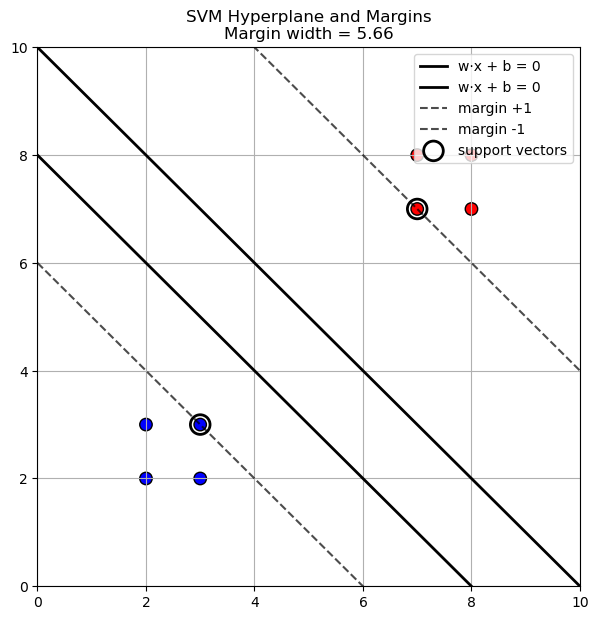

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# ----------------------------
# 1. Create simple 2D dataset
# ----------------------------
X = np.array([
    [2, 2],
    [3, 3],
    [2, 3],
    [3, 2],
    [7, 8],
    [8, 8],
    [7, 7],
    [8, 7]
])

y = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

# ----------------------------
# 2. Train linear SVM
# ----------------------------
model = svm.SVC(kernel="linear", C=1e6)  # hard-margin approx
model.fit(X, y)

# Extract parameters
w = model.coef_[0]     # weight vector
b = model.intercept_[0]

print("w:", w)
print("b:", b)

# ----------------------------
# 3. Create grid for plotting
# ----------------------------
x_vals = np.linspace(0, 10, 100)

# hyperplane: w1*x + w2*y + b = 0
# solve for y
def hyperplane(x, w, b, offset):
    return (-w[0] * x - b + offset) / w[1]

y_hyper = hyperplane(x_vals, w, b, 0)
y_margin_pos = hyperplane(x_vals, w, b, 1)
y_margin_neg = hyperplane(x_vals, w, b, -1)

# ----------------------------
# 4. Plot everything
# ----------------------------
plt.figure(figsize=(7,7))

# data points
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", s=80, edgecolors="k")

# hyperplane - light gray
plt.plot(x_vals , y_hyper , "k-", label="w·x + b = 0", linewidth=2)
plt.plot(x_vals * .8 , y_hyper * .8 , "k-", label="w·x + b = 0", linewidth=2)


# margins - even lighter
plt.plot(x_vals, y_margin_pos, "k--", label="margin +1", alpha=0.7)
plt.plot(x_vals, y_margin_neg, "k--", label="margin -1", alpha=0.7)


# support vectors
plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=200,
    facecolors="none",
    edgecolors="k",
    linewidths=2,
    label="support vectors"
)

# annotate margin width
margin_width = 2 / np.linalg.norm(w)
plt.title(f"SVM Hyperplane and Margins\nMargin width = {margin_width:.2f}")

plt.xlim(0,10)
plt.ylim(0,10)
plt.legend()
plt.grid(True)
plt.show()


### Adding Similarity Features to Solve Non-Linearity

Instance x₁ = -1.0
  x₂ = exp(-0.3 × 1²) = 0.7408
  x₃ = exp(-0.3 × 2²) = 0.3012


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/rbf_similarity_demo.png'

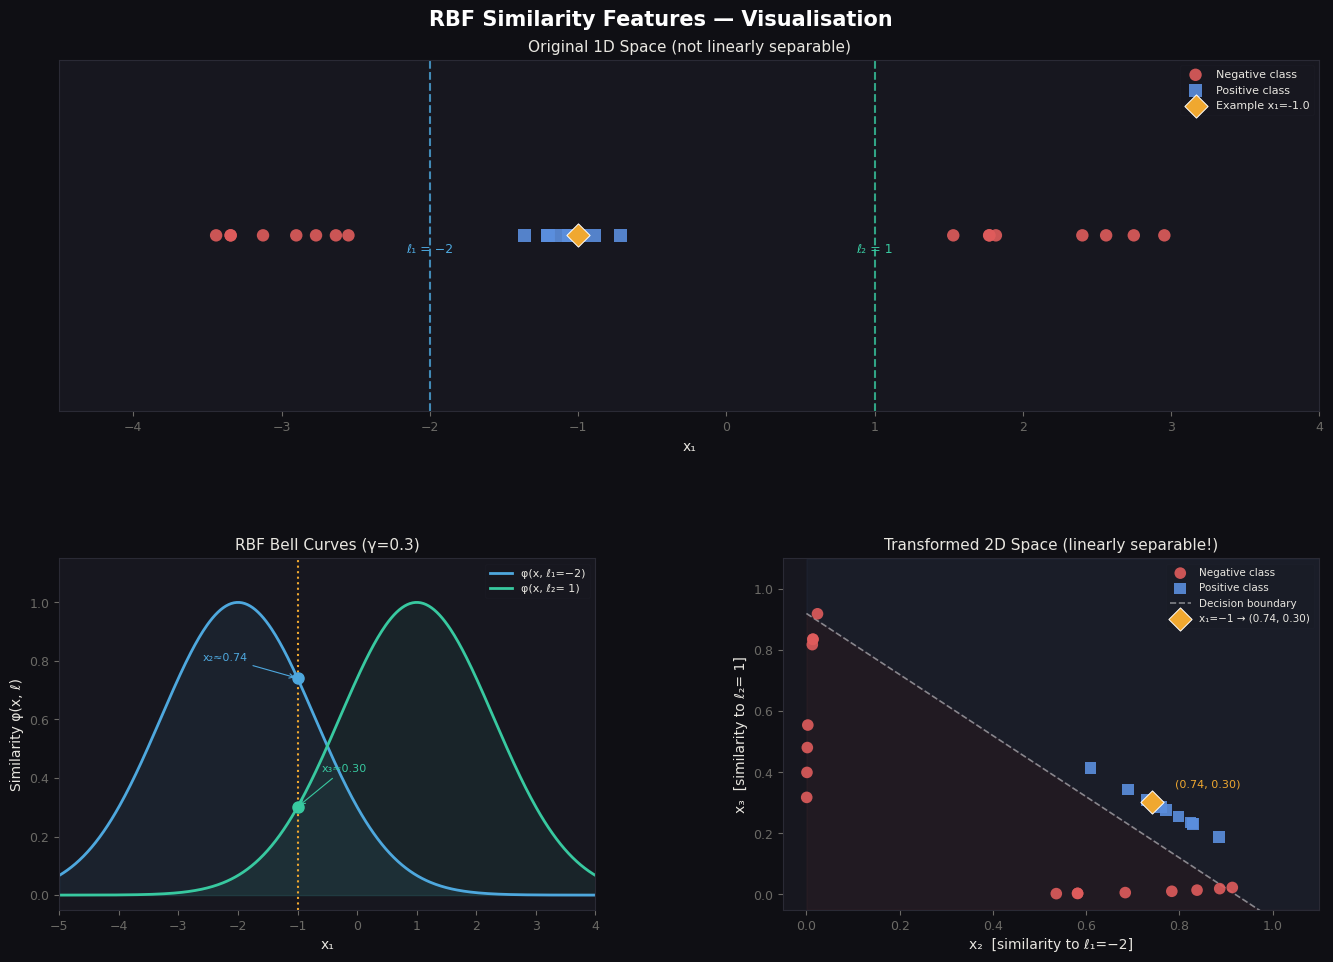

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Data & parameters ────────────────────────────────────────────────────────
np.random.seed(42)
gamma = 0.3
landmarks = np.array([-2.0, 1.0])

# 1D dataset: two "positive" clusters near -1, rest are "negative"
X_neg = np.concatenate(
    [np.random.uniform(-3.5, -2.5, 8), np.random.uniform(1.5, 3.0, 8)]
)
X_pos = np.random.uniform(-1.5, -0.5, 10)
X = np.concatenate([X_neg, X_pos])
y = np.array([0] * len(X_neg) + [1] * len(X_pos))


# ── RBF transformation ────────────────────────────────────────────────────────
def rbf(x, landmark, gamma):
    return np.exp(-gamma * (x - landmark) ** 2)


def transform(X, landmarks, gamma):
    return np.column_stack([rbf(X, l, gamma) for l in landmarks])


X_transformed = transform(X, landmarks, gamma)

# ── Bell-curve data for visualisation ────────────────────────────────────────
x_range = np.linspace(-5, 4, 400)
bell1 = rbf(x_range, landmarks[0], gamma)
bell2 = rbf(x_range, landmarks[1], gamma)

# ── Example point ─────────────────────────────────────────────────────────────
x_example = -1.0
x2_ex = rbf(x_example, landmarks[0], gamma)
x3_ex = rbf(x_example, landmarks[1], gamma)
print(f"Instance x₁ = {x_example}")
print(f"  x₂ = exp(-{gamma} × {abs(x_example - landmarks[0]):.0f}²) = {x2_ex:.4f}")
print(f"  x₃ = exp(-{gamma} × {abs(x_example - landmarks[1]):.0f}²) = {x3_ex:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10), facecolor="#0f0f14")
fig.suptitle(
    "RBF Similarity Features — Visualisation",
    fontsize=15,
    color="white",
    y=0.97,
    fontweight="bold",
)

gs = gridspec.GridSpec(
    2,
    2,
    figure=fig,
    hspace=0.42,
    wspace=0.35,
    left=0.07,
    right=0.97,
    top=0.92,
    bottom=0.07,
)

ax_1d = fig.add_subplot(gs[0, :])  # full width: original 1D space
ax_bell = fig.add_subplot(gs[1, 0])  # bell curves
ax_2d = fig.add_subplot(gs[1, 1])  # transformed 2D space

colors = {0: "#e05c5c", 1: "#5b8fde"}
labels = {0: "Negative class", 1: "Positive class"}
markers = {0: "o", 1: "s"}

# Palette
bg = "#0f0f14"
fg = "#e8e6e0"
dim = "#6b6a66"
blue = "#4ea8de"
teal = "#38c9a0"

for ax in [ax_1d, ax_bell, ax_2d]:
    ax.set_facecolor("#17171f")
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2a35")
    ax.tick_params(colors=dim, labelsize=9)
    ax.xaxis.label.set_color(fg)
    ax.yaxis.label.set_color(fg)
    ax.title.set_color(fg)

# ── Panel 1: Original 1D space ────────────────────────────────────────────────
ax_1d.set_title("Original 1D Space (not linearly separable)", fontsize=11)
ax_1d.set_xlabel("x₁")
ax_1d.set_yticks([])
ax_1d.set_xlim(-4.5, 4)

for cls in [0, 1]:
    mask = y == cls
    ax_1d.scatter(
        X[mask],
        np.zeros(mask.sum()),
        c=colors[cls],
        marker=markers[cls],
        s=80,
        zorder=3,
        label=labels[cls],
        edgecolors="none",
        alpha=0.9,
    )

for i, (lx, col, name) in enumerate(
    zip(landmarks, [blue, teal], ["ℓ₁ = −2", "ℓ₂ = 1"])
):
    ax_1d.axvline(lx, color=col, linestyle="--", linewidth=1.5, alpha=0.8)
    ax_1d.text(
        lx,
        0.45,
        name,
        ha="center",
        fontsize=9,
        color=col,
        transform=ax_1d.get_xaxis_transform(),
    )

ax_1d.scatter(
    [x_example],
    [0],
    c="#f0a830",
    s=140,
    zorder=5,
    marker="D",
    edgecolors="white",
    linewidths=0.7,
    label=f"Example x₁={x_example}",
)
ax_1d.legend(
    loc="upper right",
    fontsize=8,
    framealpha=0.15,
    labelcolor=fg,
    facecolor="#17171f",
    edgecolor="#2a2a35",
)

# ── Panel 2: Bell curves ──────────────────────────────────────────────────────
ax_bell.set_title("RBF Bell Curves (γ=0.3)", fontsize=11)
ax_bell.set_xlabel("x₁")
ax_bell.set_ylabel("Similarity φ(x, ℓ)")
ax_bell.set_xlim(-5, 4)
ax_bell.set_ylim(-0.05, 1.15)

ax_bell.plot(x_range, bell1, color=blue, lw=2, label="φ(x, ℓ₁=−2)")
ax_bell.plot(x_range, bell2, color=teal, lw=2, label="φ(x, ℓ₂= 1)")
ax_bell.fill_between(x_range, bell1, alpha=0.08, color=blue)
ax_bell.fill_between(x_range, bell2, alpha=0.08, color=teal)

ax_bell.axvline(x_example, color="#f0a830", linestyle=":", lw=1.5)
ax_bell.plot(x_example, x2_ex, "o", color=blue, ms=8, zorder=5)
ax_bell.plot(x_example, x3_ex, "o", color=teal, ms=8, zorder=5)
ax_bell.annotate(
    f"x₂≈{x2_ex:.2f}",
    (x_example, x2_ex),
    xytext=(x_example - 1.6, x2_ex + 0.06),
    fontsize=8,
    color=blue,
    arrowprops=dict(arrowstyle="->", color=blue, lw=0.8),
)
ax_bell.annotate(
    f"x₃≈{x3_ex:.2f}",
    (x_example, x3_ex),
    xytext=(x_example + 0.4, x3_ex + 0.12),
    fontsize=8,
    color=teal,
    arrowprops=dict(arrowstyle="->", color=teal, lw=0.8),
)

ax_bell.legend(
    fontsize=8, framealpha=0.15, labelcolor=fg, facecolor="#17171f", edgecolor="#2a2a35"
)

# ── Panel 3: Transformed 2D space ─────────────────────────────────────────────
ax_2d.set_title("Transformed 2D Space (linearly separable!)", fontsize=11)
ax_2d.set_xlabel("x₂  [similarity to ℓ₁=−2]")
ax_2d.set_ylabel("x₃  [similarity to ℓ₂= 1]")
ax_2d.set_xlim(-0.05, 1.1)
ax_2d.set_ylim(-0.05, 1.1)

for cls in [0, 1]:
    mask = y == cls
    ax_2d.scatter(
        X_transformed[mask, 0],
        X_transformed[mask, 1],
        c=colors[cls],
        marker=markers[cls],
        s=70,
        zorder=3,
        label=labels[cls],
        edgecolors="none",
        alpha=0.9,
    )

# Approximate decision boundary (diagonal)
db_x = np.linspace(0, 1.1, 100)
db_y = 0.92 - db_x
ax_2d.plot(
    db_x, db_y, "--", color="white", lw=1.2, alpha=0.45, label="Decision boundary"
)
ax_2d.fill_between(db_x, db_y, 1.1, alpha=0.05, color="#5b8fde")
ax_2d.fill_between(db_x, -0.05, db_y, alpha=0.05, color="#e05c5c")

# Example point
ax_2d.scatter(
    [x2_ex],
    [x3_ex],
    c="#f0a830",
    s=140,
    zorder=5,
    marker="D",
    edgecolors="white",
    linewidths=0.7,
    label=f"x₁=−1 → ({x2_ex:.2f}, {x3_ex:.2f})",
)
ax_2d.annotate(
    f"({x2_ex:.2f}, {x3_ex:.2f})",
    (x2_ex, x3_ex),
    xytext=(x2_ex + 0.05, x3_ex + 0.05),
    fontsize=8,
    color="#f0a830",
)

ax_2d.legend(
    fontsize=7.5,
    framealpha=0.15,
    labelcolor=fg,
    facecolor="#17171f",
    edgecolor="#2a2a35",
)


plt.show()